
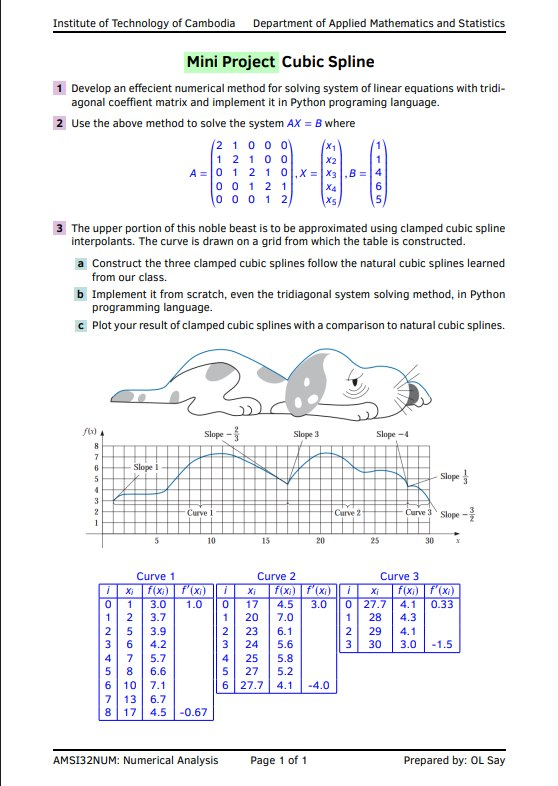

# Problem 1

In [1]:
import numpy as np

def solve_tridiagonal(A_matrix, B_vector):
    """
    Solves AX = B where A is a tridiagonal matrix using the Thomas Algorithm.
    Extracts sub-diagonal (a), main diagonal (b), and super-diagonal (c) 
    dynamically from the input matrix A.
    """
    n = len(B_vector)
    a = np.zeros(n)  # Sub-diagonal (below main)
    b = np.zeros(n)  # Main diagonal
    c = np.zeros(n)  # Super-diagonal (above main)
    
    # Extract elements into standard tridiagonal arrays
    b[0] = A_matrix[0, 0]
    c[0] = A_matrix[0, 1]
    for i in range(1, n - 1):
        a[i] = A_matrix[i, i - 1]
        b[i] = A_matrix[i, i]
        c[i] = A_matrix[i, i + 1]
    a[n - 1] = A_matrix[n - 1, n - 2]
    b[n - 1] = A_matrix[n - 1, n - 1]
    
    # Forward sweep phase
    c_prime = np.zeros(n)
    d_prime = np.zeros(n)
    
    c_prime[0] = c[0] / b[0]
    d_prime[0] = B_vector[0] / b[0]
    
    for i in range(1, n):
        denominator = b[i] - a[i] * c_prime[i - 1]
        if i < n - 1:
            c_prime[i] = c[i] / denominator
        d_prime[i] = (B_vector[i] - a[i] * d_prime[i - 1]) / denominator
        
    # Backward substitution phase
    X = np.zeros(n)
    X[n - 1] = d_prime[n - 1]
    for i in range(n - 2, -1, -1):
        X[i] = d_prime[i] - c_prime[i] * X[i + 1]
        
    return X

print("Thomas Algorithm function successfully defined.")

Thomas Algorithm function successfully defined.


# Problem 2


In [2]:
import numpy as np

# Paste the function from Problem 1 here so it can execute independently
def solve_tridiagonal(A_matrix, B_vector):
    n = len(B_vector)
    a, b, c = np.zeros(n), np.zeros(n), np.zeros(n)
    b[0], c[0] = A_matrix[0, 0], A_matrix[0, 1]
    for i in range(1, n - 1):
        a[i], b[i], c[i] = A_matrix[i, i - 1], A_matrix[i, i], A_matrix[i, i + 1]
    a[n - 1], b[n - 1] = A_matrix[n - 1, n - 2], A_matrix[n - 1, n - 1]
    
    c_prime, d_prime = np.zeros(n), np.zeros(n)
    c_prime[0], d_prime[0] = c[0] / b[0], B_vector[0] / b[0]
    
    for i in range(1, n):
        den = b[i] - a[i] * c_prime[i - 1]
        if i < n - 1: c_prime[i] = c[i] / den
        d_prime[i] = (B_vector[i] - a[i] * d_prime[i - 1]) / den
        
    X = np.zeros(n)
    X[n - 1] = d_prime[n - 1]
    for i in range(n - 2, -1, -1):
        X[i] = d_prime[i] - c_prime[i] * X[i + 1]
    return X

# --- Problem 2 Matrix and Vector Input ---
A = np.array([
    [2, 1, 0, 0, 0],
    [1, 2, 1, 0, 0],
    [0, 1, 2, 1, 0],
    [0, 0, 1, 2, 1],
    [0, 0, 0, 1, 2]
], dtype=float)

B = np.array([1, 1, 4, 6, 5], dtype=float)

# Execute Solver
X_solution = solve_tridiagonal(A, B)

# Display Results
print("--- Solution to the System AX = B ---")
for i, val in enumerate(X_solution, start=1):
    print(f"x_{i} = {val:.4f}")

--- Solution to the System AX = B ---
x_1 = 1.0000
x_2 = -1.0000
x_3 = 2.0000
x_4 = 1.0000
x_5 = 2.0000


# Problem 3


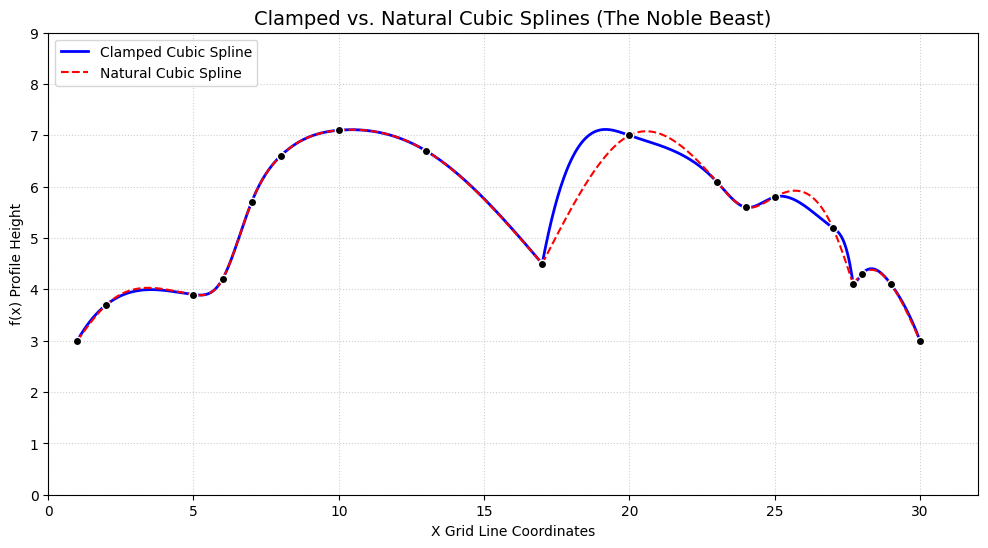

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Dependent Solver Engine
def solve_tridiagonal(A_matrix, B_vector):
    n = len(B_vector)
    a, b, c = np.zeros(n), np.zeros(n), np.zeros(n)
    b[0], c[0] = A_matrix[0, 0], A_matrix[0, 1]
    for i in range(1, n - 1):
        a[i], b[i], c[i] = A_matrix[i, i - 1], A_matrix[i, i], A_matrix[i, i + 1]
    a[n - 1], b[n - 1] = A_matrix[n - 1, n - 2], A_matrix[n - 1, n - 1]
    c_prime, d_prime = np.zeros(n), np.zeros(n)
    c_prime[0], d_prime[0] = c[0] / b[0], B_vector[0] / b[0]
    for i in range(1, n):
        den = b[i] - a[i] * c_prime[i - 1]
        if i < n - 1: c_prime[i] = c[i] / den
        d_prime[i] = (B_vector[i] - a[i] * d_prime[i - 1]) / den
    X = np.zeros(n)
    X[n - 1] = d_prime[n - 1]
    for i in range(n - 2, -1, -1):
        X[i] = d_prime[i] - c_prime[i] * X[i + 1]
    return X

def compute_cubic_spline_coefficients(x, y, boundary_type='natural', f_prime_start=0.0, f_prime_end=0.0):
    """Computes a, b, c, d piecewise spline coefficients."""
    n = len(x) - 1
    h = np.diff(x)
    a = np.array(y, dtype=float)
    A_mat = np.zeros((n + 1, n + 1))
    B_vec = np.zeros(n + 1)
    
    for i in range(1, n):
        A_mat[i, i - 1] = h[i - 1]
        A_mat[i, i] = 2 * (h[i - 1] + h[i])
        A_mat[i, i + 1] = h[i]
        B_vec[i] = (3 / h[i]) * (a[i + 1] - a[i]) - (3 / h[i - 1]) * (a[i] - a[i - 1])
        
    if boundary_type == 'natural':
        A_mat[0, 0], A_mat[n, n] = 1, 1
    elif boundary_type == 'clamped':
        A_mat[0, 0], A_mat[0, 1] = 2 * h[0], h[0]
        B_vec[0] = (3 / h[0]) * (a[1] - a[0]) - 3 * f_prime_start
        A_mat[n, n - 1], A_mat[n, n] = h[n - 1], 2 * h[n - 1]
        B_vec[n] = 3 * f_prime_end - (3 / h[n - 1]) * (a[n] - a[n - 1])
        
    c = solve_tridiagonal(A_mat, B_vec)
    b, d = np.zeros(n), np.zeros(n)
    for i in range(n):
        b[i] = (a[i + 1] - a[i]) / h[i] - h[i] * (2 * c[i] + c[i + 1]) / 3
        d[i] = (c[i + 1] - c[i]) / (3 * h[i])
    return a[:-1], b, c[:-1], d

def evaluate_spline(x_nodes, x_eval, a, b, c, d):
    """Maps dynamic math formulas into a continuous plot line."""
    y_eval = np.zeros_like(x_eval)
    for i in range(len(x_nodes) - 1):
        mask = (x_eval >= x_nodes[i]) & (x_eval <= x_nodes[i + 1])
        if i == len(x_nodes) - 2:
            mask = mask | (x_eval >= x_nodes[i + 1])
        dx = x_eval[mask] - x_nodes[i]
        y_eval[mask] = a[i] + b[i] * dx + c[i] * (dx**2) + d[i] * (dx**3)
    return y_eval

# --- Node Datasets from Image Tables ---
curves = [
    {
        "name": "Curve 1",
        "x": np.array([1, 2, 5, 6, 7, 8, 10, 13, 17], dtype=float),
        "y": np.array([3.0, 3.7, 3.9, 4.2, 5.7, 6.6, 7.1, 6.7, 4.5], dtype=float),
        "fp_s": 1.0, "fp_e": -0.67
    },
    {
        "name": "Curve 2",
        "x": np.array([17, 20, 23, 24, 25, 27, 27.7], dtype=float),
        "y": np.array([4.5, 7.0, 6.1, 5.6, 5.8, 5.2, 4.1], dtype=float),
        "fp_s": 3.0, "fp_e": -4.0
    },
    {
        "name": "Curve 3",
        "x": np.array([27.7, 28, 29, 30], dtype=float),
        "y": np.array([4.1, 4.3, 4.1, 3.0], dtype=float),
        "fp_s": 0.33, "fp_e": -1.5
    }
]

# Plot Generation Configuration
plt.figure(figsize=(12, 6))

for curve in curves:
    x_nodes, y_nodes = curve["x"], curve["y"]
    x_fine = np.linspace(x_nodes[0], x_nodes[-1], 300)
    
    # Evaluate Clamped Condition
    ac, bc, cc, dc = compute_cubic_spline_coefficients(x_nodes, y_nodes, 'clamped', curve["fp_s"], curve["fp_e"])
    y_clamped = evaluate_spline(x_nodes, x_fine, ac, bc, cc, dc)
    
    # Evaluate Natural Condition
    an, bn, cn, dn = compute_cubic_spline_coefficients(x_nodes, y_nodes, 'natural')
    y_natural = evaluate_spline(x_nodes, x_fine, an, bn, cn, dn)
    
    # Handle legends properly without repeat entries
    label_c, label_n = (('Clamped Cubic Spline', 'Natural Cubic Spline') 
                       if curve["name"] == "Curve 1" else (None, None))
    
    plt.plot(x_fine, y_clamped, 'b-', linewidth=2, label=label_c)
    plt.plot(x_fine, y_natural, 'r--', linewidth=1.5, label=label_n)
    plt.scatter(x_nodes, y_nodes, color='black', edgecolor='w', zorder=5)

plt.title("Clamped vs. Natural Cubic Splines (The Noble Beast)", fontsize=14)
plt.xlabel("X Grid Line Coordinates")
plt.ylabel("f(x) Profile Height")
plt.xlim(0, 32)
plt.ylim(0, 9)
plt.grid(True, which='both', linestyle=':', alpha=0.6)
plt.legend(loc='upper left')
plt.show()